In [3]:
import numpy as np 
import matplotlib.pyplot as plt

def science_plot(fontsize=9, scistyle=True, show_latex=True):
    # Default settings (applied to both 2D and 3D)
    if scistyle:
        import scienceplots
        plt.style.use(['science','grid','notebook'])
    if show_latex:
        plt.rcParams.update({
            # Latex Use
            'text.usetex'     : True,        # Use LaTeX for text rendering
            'font.family'     : 'serif',     # Set font family to serif
        })

    plt.rcParams.update({
        # Fontsizes
        'font.size'       : fontsize,    # General font size
        'axes.titlesize'  : fontsize,    # Font size of the axes title
        'axes.labelsize'  : fontsize,    # Font size of the axes labels
        'xtick.labelsize' : fontsize,    # Font size of the x-axis tick labels
        'ytick.labelsize' : fontsize,    # Font size of the y-axis tick labels
        'legend.fontsize' : fontsize,    # Font size of the legend
        'figure.titlesize': fontsize,    # Font size of the figure title

        # Legend
        'legend.fancybox' : False,       # Disable the fancy box for legend
        'legend.edgecolor': 'k',         # Set legend border color to black
    })
science_plot(fontsize=9)

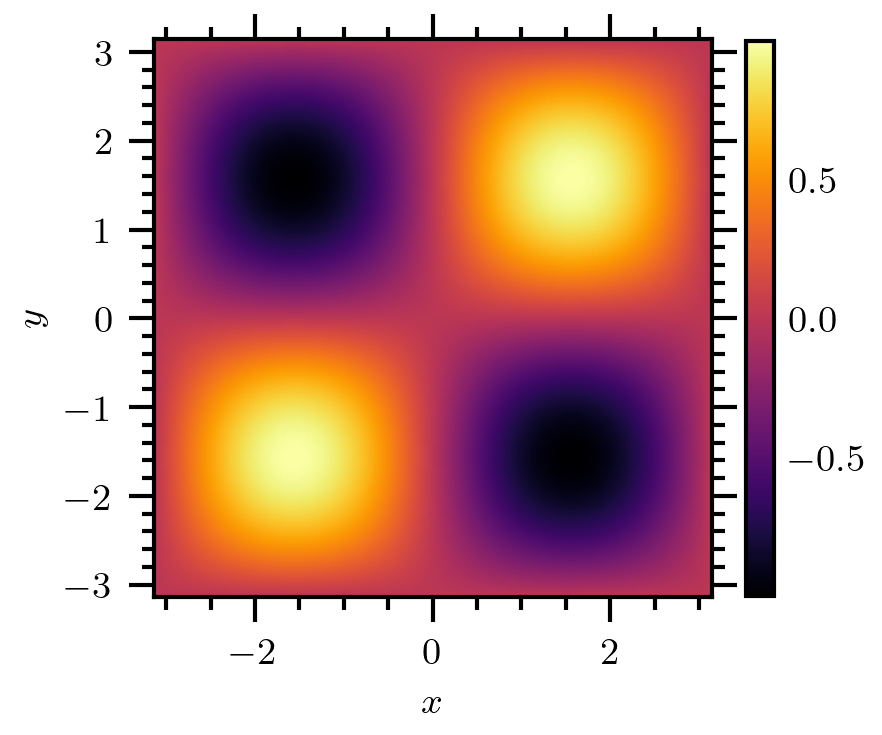

In [14]:
x = y = np.linspace(-np.pi, np.pi, 200)  # Extended range to see more periods
X, Y = np.meshgrid(x, y, indexing='ij')
F = np.sin(X) * np.sin(Y)

plt.figure(figsize=(3, 3), dpi=300)
plt.imshow(F.T, extent=[-np.pi, np.pi, -np.pi, np.pi], 
           cmap='inferno', origin='lower')
plt.grid(False)
plt.xlabel(r'$x$')
plt.ylabel(r'$y$')  # Fixed: was using xlabel twice
plt.colorbar(shrink=0.8)
plt.tick_params(axis='both', which='major', direction='out')
plt.tick_params(axis='both', which='minor', direction='out')
plt.show()

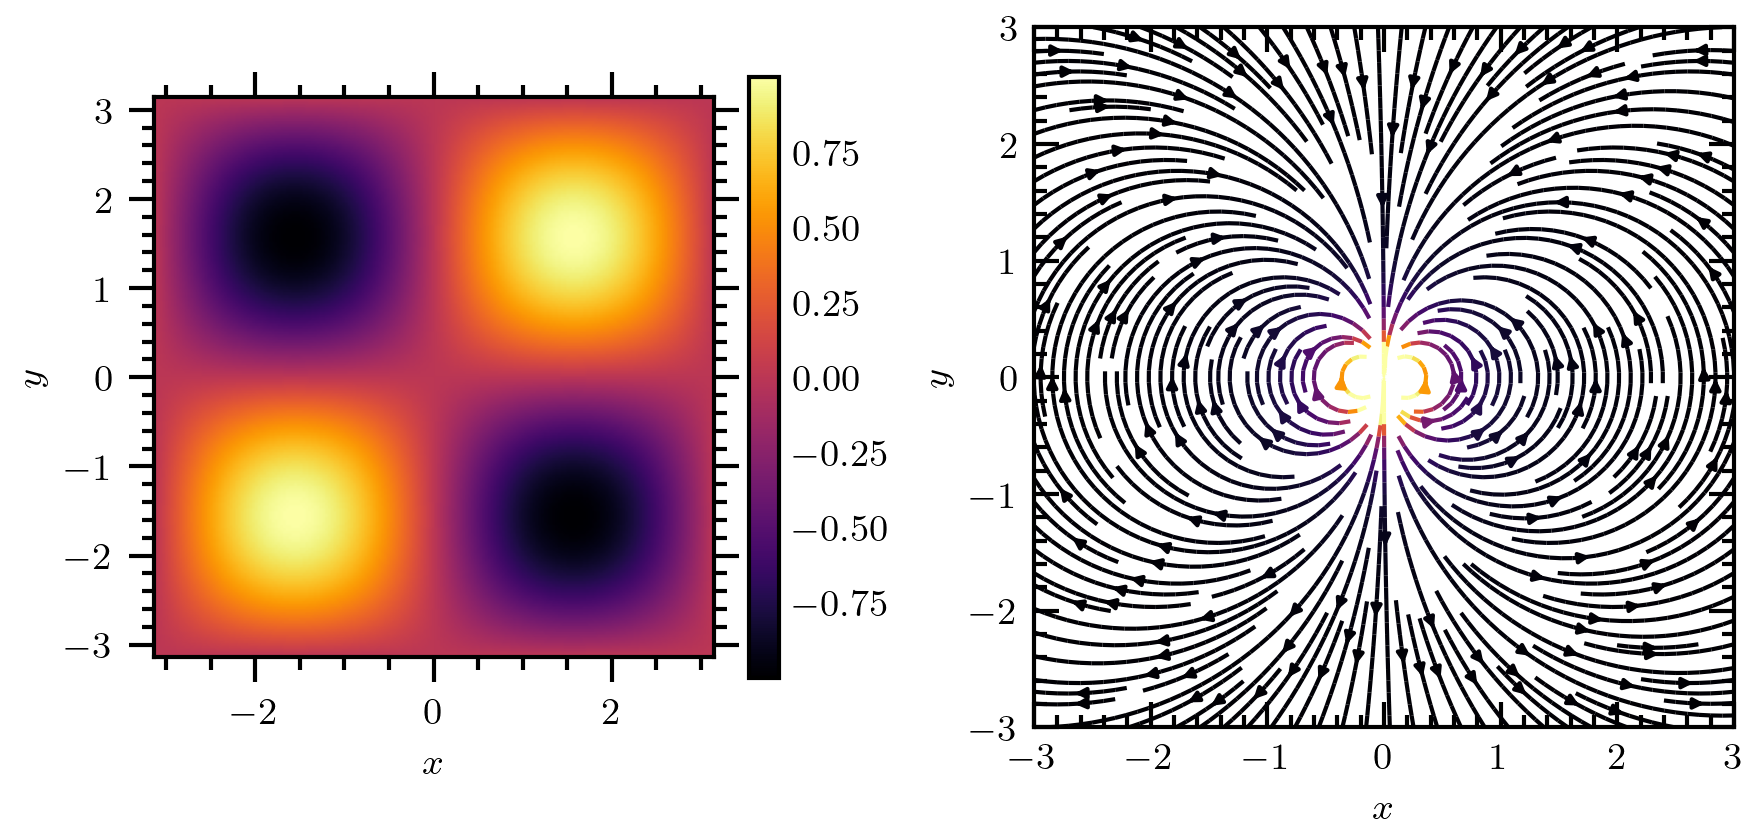

In [30]:
import numpy as np
import matplotlib.pyplot as plt

# Create figure with 2 subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(6, 3), dpi=300)

# First plot: sin(x)sin(y) field
x = y = np.linspace(-np.pi, np.pi, 200)
X1, Y1 = np.meshgrid(x, y, indexing='ij')
F1 = np.sin(X1) * np.sin(Y1)

im1 = ax1.imshow(F1.T, extent=[-np.pi, np.pi, -np.pi, np.pi], 
                 cmap='inferno', origin='lower')
ax1.grid(False)
ax1.set_xlabel(r'$x$')
ax1.set_ylabel(r'$y$')
ax1.tick_params(axis='both', which='major', direction='out')
ax1.tick_params(axis='both', which='minor', direction='out')
plt.colorbar(im1, ax=ax1, shrink=0.8)

# Second plot: Dipole vector field
x = np.linspace(-3, 3, 150)
y = np.linspace(-3, 3, 150)
X2, Y2 = np.meshgrid(x, y)
Z = X2 + 1j*Y2

epsilon = 1e-8
F2 = -1j / (Z**2 + epsilon)

Ex = np.real(F2)
Ey = -np.imag(F2)
magnitude = np.sqrt(Ex**2 + Ey**2)
mmax = 10
magnitude[magnitude > mmax] = mmax

stream = ax2.streamplot(X2, Y2, Ex, Ey, color=magnitude, cmap='inferno',
                        density=2, linewidth=1, arrowsize=0.5)
ax2.set_xlabel(r'$x$')
ax2.set_ylabel(r'$y$')
ax2.grid(False)
ax2.set_aspect('equal')

# Adjust layout and show
plt.tight_layout()
plt.show()

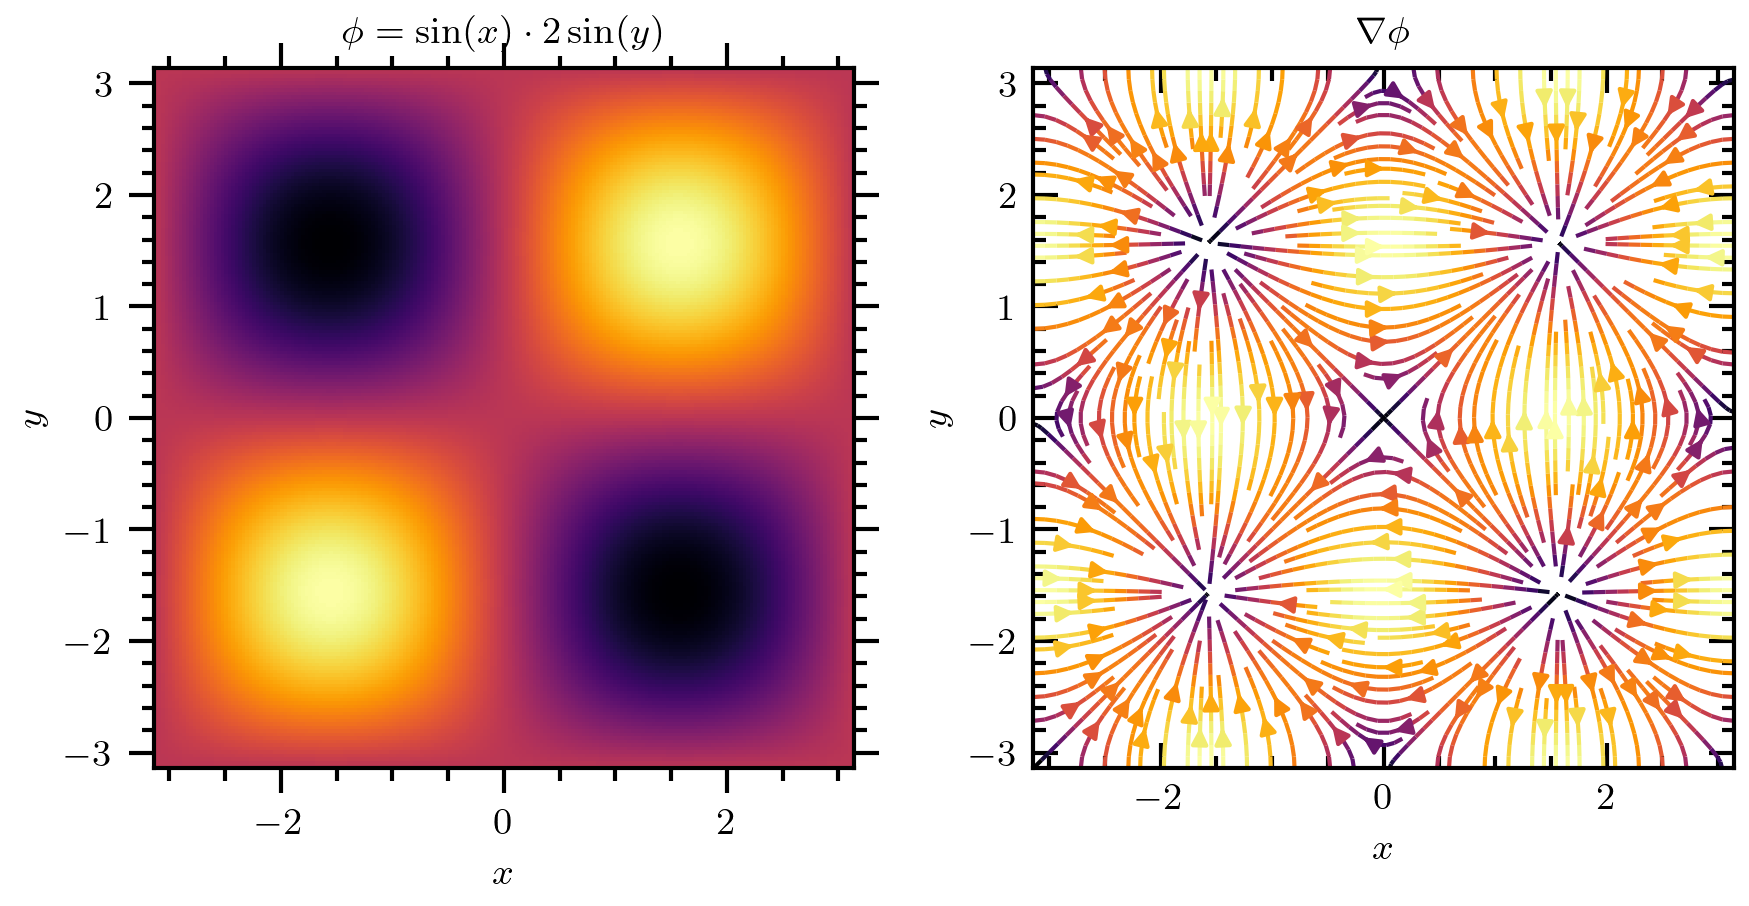

In [32]:
import numpy as np
import matplotlib.pyplot as plt

# Create data
x = y = np.linspace(-np.pi, np.pi, 200)
X, Y = np.meshgrid(x, y, indexing='xy')  # Use 'xy' for streamplot compatibility
F = np.sin(X) * 2 * np.sin(Y)  # Scalar field φ

# Compute gradient ∇φ
Fx = np.gradient(F, x, axis=1)  # ∂φ/∂x
Fy = np.gradient(F, y, axis=0)  # ∂φ/∂y

# Create figure with 2 subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(6, 3), dpi=300)

# First plot: Scalar field φ
im1 = ax1.imshow(F, extent=[-np.pi, np.pi, -np.pi, np.pi], 
                 cmap='inferno', origin='lower')
ax1.grid(False)
ax1.set_xlabel(r'$x$')
ax1.set_ylabel(r'$y$')
ax1.set_title(r'$\phi = \sin(x)\cdot 2\sin(y)$')
ax1.tick_params(axis='both', which='major', direction='out')
ax1.tick_params(axis='both', which='minor', direction='out')
ax1.set_aspect('equal')

# Second plot: Gradient field ∇φ
magnitude = np.sqrt(Fx**2 + Fy**2)
stream = ax2.streamplot(X, Y, Fx, Fy, color=magnitude, cmap='inferno',
                        density=2, linewidth=1, arrowsize=0.8)
ax2.grid(False)
ax2.set_xlabel(r'$x$')
ax2.set_ylabel(r'$y$')
ax2.set_title(r'$\nabla \phi$')
ax2.set_xlim(-np.pi, np.pi)
ax2.set_ylim(-np.pi, np.pi)
ax2.set_aspect('equal')

# Adjust layout and show
plt.tight_layout()
plt.show()

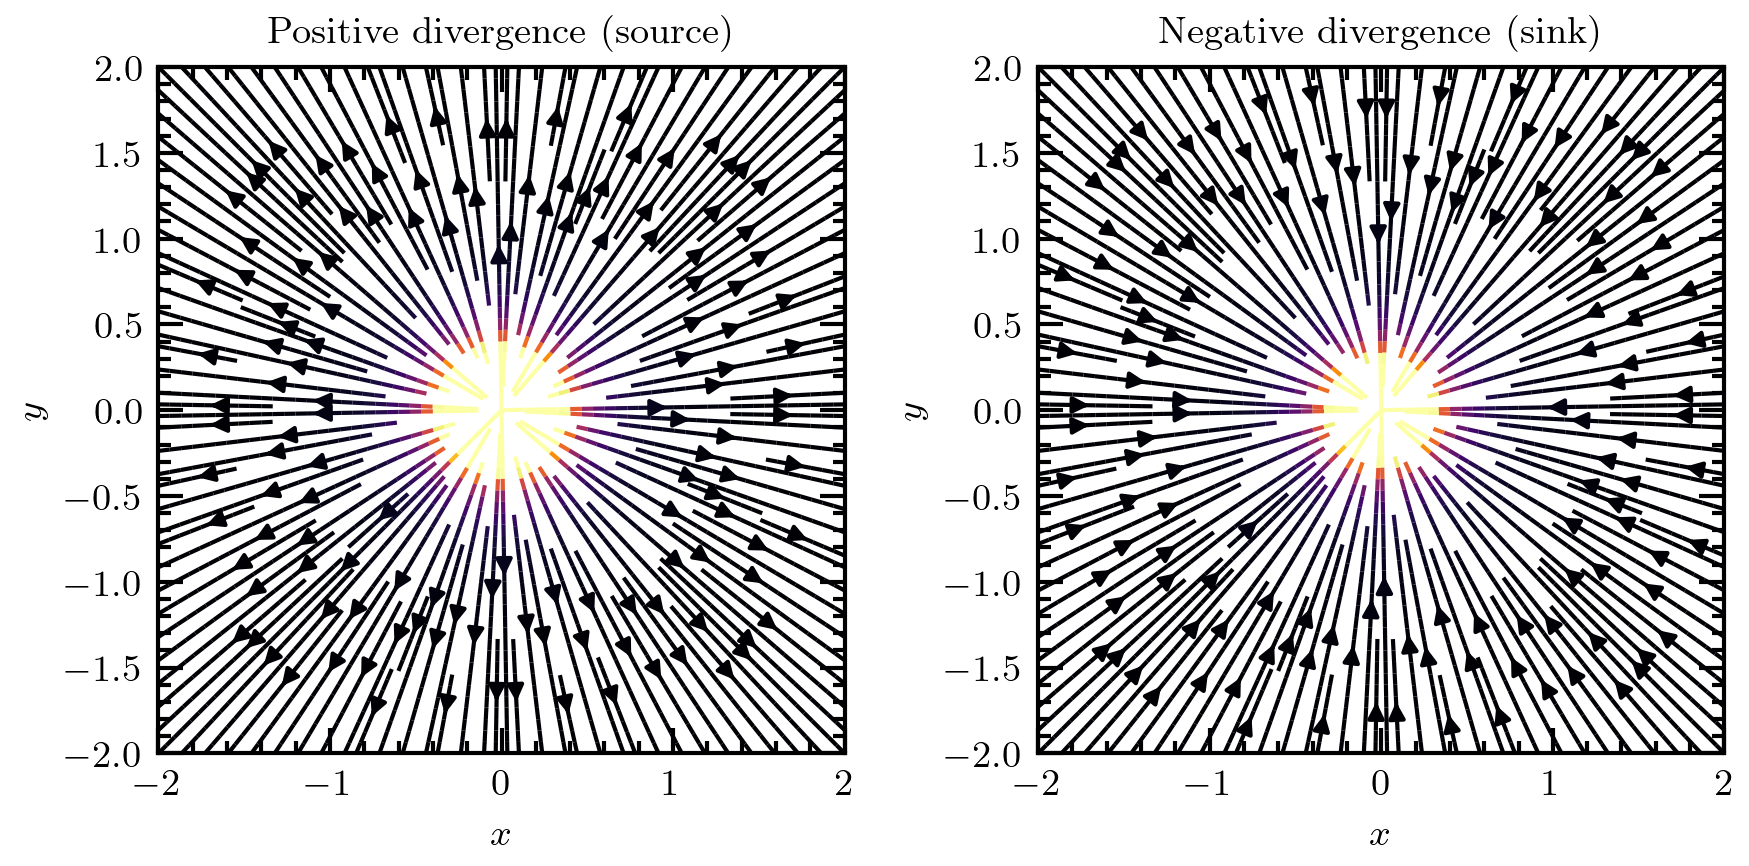

In [39]:
x = y = np.linspace(-2,2,200)
X,Y = np.meshgrid(x,y)
R = np.sqrt(X*X+Y*Y)

eps=1e-12
Fpos = -1/(R**2+eps)
Fneg =  1/(R**2+eps)

Fposx = np.gradient(Fpos,x, edge_order = 2, axis=1)
Fposy = np.gradient(Fpos,y, edge_order = 2, axis=0)
Fnegx = np.gradient(Fneg,x, edge_order = 2, axis=1)
Fnegy = np.gradient(Fneg,y, edge_order = 2, axis=0)

vmin,vmax = -20,50
magpos = np.sqrt(Fposx**2+Fposy**2)
magpos[magpos>vmax]=vmax
magneg = np.sqrt(Fnegx**2+Fnegy**2)
magneg[magneg>vmax]=vmax
fig, ax = plt.subplots(1,2, figsize = (6,3),dpi=300)
ax[0].streamplot(X,Y,Fposx,Fposy,color=magpos, cmap='inferno', density=2, linewidth=1, arrowsize=0.8)
ax[1].streamplot(X,Y,Fnegx,Fnegy,color=magneg, cmap='inferno', density=2, linewidth=1, arrowsize=0.8)
ax[0].set_title('Positive divergence (source)')
ax[1].set_title('Negative divergence  (sink) ')
for axs in ax:
    axs.set_xlabel(r'$x$')
    axs.set_ylabel(r'$y$')
    axs.set_xlim(x.min(), x.max())
    axs.set_ylim(y.min(), y.max())
    axs.set_aspect('equal')
    axs.grid(False)
plt.tight_layout()
plt.show()

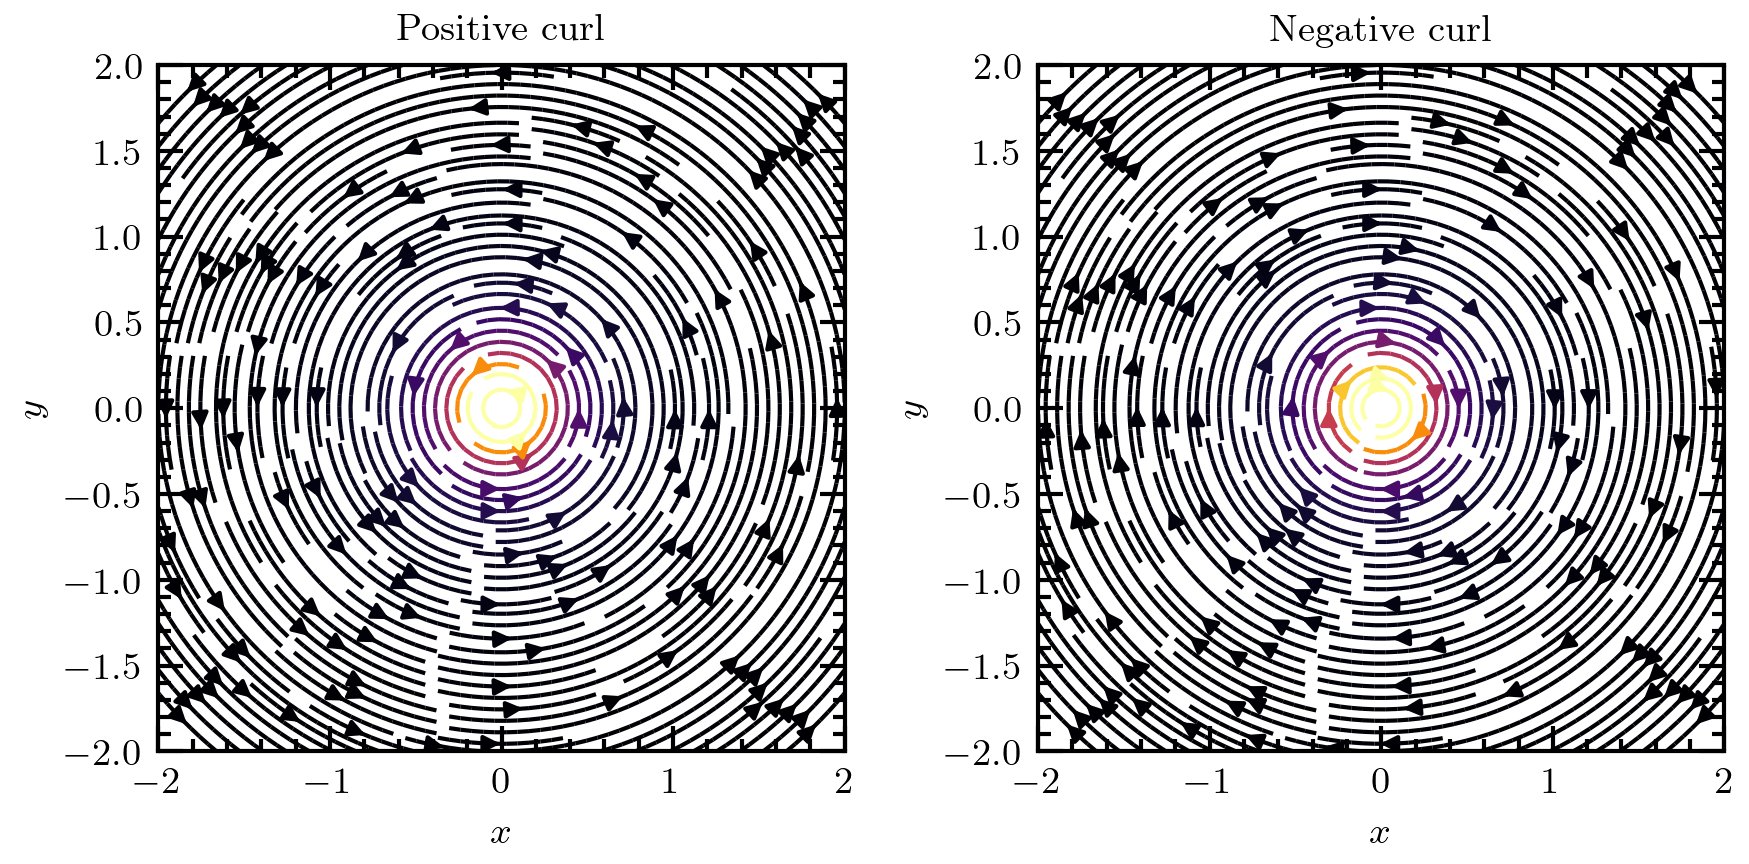

In [41]:
x = y = np.linspace(-2, 2, 200)
X, Y = np.meshgrid(x, y)
R = np.sqrt(X*X + Y*Y)

eps = 1e-12

# True 1/r^2 magnitude decay for tangential fields
# Unit tangent vector components
Fpos_x = -Y / (R + eps)
Fpos_y = X / (R + eps)

Fneg_x = Y / (R + eps)  
Fneg_y = -X / (R + eps)

# # Apply 1/r^2 magnitude scaling
magnitude_factor = 1 / (R**2 + eps)
Fpos_x *= magnitude_factor
Fpos_y *= magnitude_factor
Fneg_x *= magnitude_factor  
Fneg_y *= magnitude_factor

vmin, vmax = 0, 20
magpos = np.sqrt(Fpos_x**2 + Fpos_y**2)
magpos[magpos > vmax] = vmax
magneg = np.sqrt(Fneg_x**2 + Fneg_y**2)
magneg[magneg > vmax] = vmax

fig, ax = plt.subplots(1, 2, figsize=(6, 3), dpi=300)
ax[0].streamplot(X, Y, Fpos_x, Fpos_y, color=magpos, cmap='inferno', 
                 density=2, linewidth=1, arrowsize=0.8)
ax[1].streamplot(X, Y, Fneg_x, Fneg_y, color=magneg, cmap='inferno', 
                 density=2, linewidth=1, arrowsize=0.8)
ax[0].set_title('Positive curl')
ax[1].set_title('Negative curl')
for axs in ax:
    axs.set_xlabel(r'$x$')
    axs.set_ylabel(r'$y$')
    axs.set_xlim(x.min(), x.max())
    axs.set_ylim(y.min(), y.max())
    axs.set_aspect('equal')
    axs.grid(False)
plt.tight_layout()
plt.show()

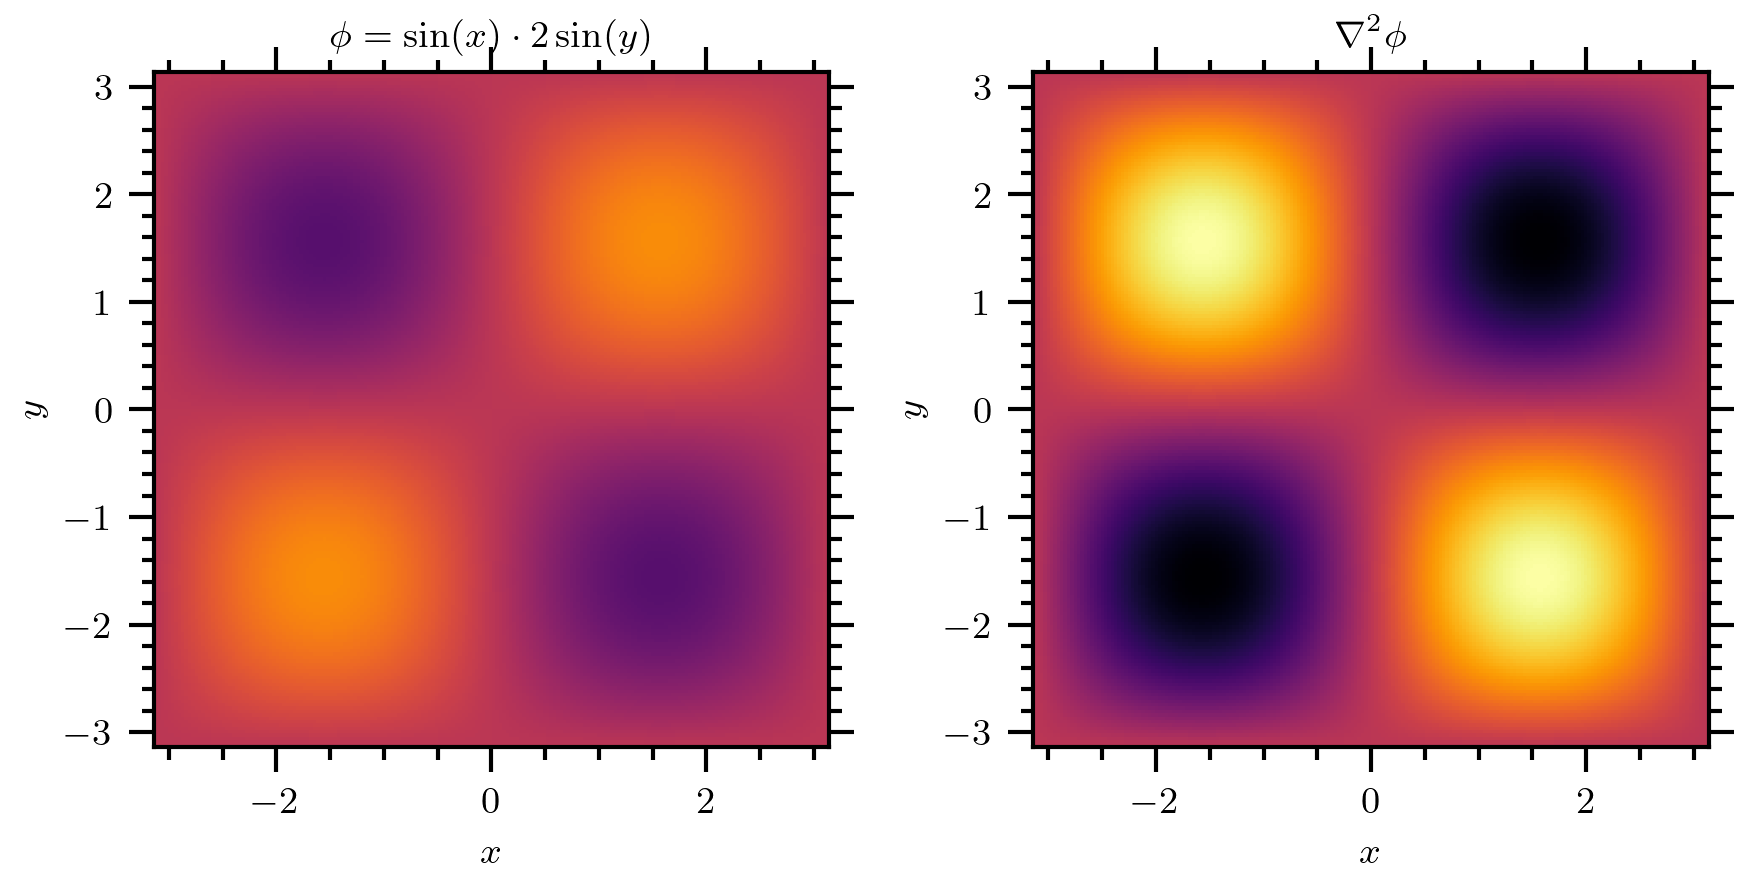

In [46]:
import numpy as np
import matplotlib.pyplot as plt

# Create data
x = y = np.linspace(-np.pi, np.pi, 200)
X, Y = np.meshgrid(x, y, indexing='xy')  # Use 'xy' for streamplot compatibility
F = np.sin(X) * np.sin(Y)  # Scalar field φ

# Compute gradient ∇φ
Fx = np.gradient(F, x, axis=1)  # ∂φ/∂x
Fy = np.gradient(F, y, axis=0)  # ∂φ/∂y

# Compute Laplacian ∇²φ = ∂²φ/∂x² + ∂²φ/∂y²
Fxx = np.gradient(Fx, x, axis=1)  # ∂²φ/∂x²
Fyy = np.gradient(Fy, y, axis=0)  # ∂²φ/∂y²
laplacian = Fxx + Fyy

# Create figure with 2 subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(6, 3), dpi=300)

# First plot: Scalar field φ
im1 = ax1.imshow(F, extent=[-np.pi, np.pi, -np.pi, np.pi], 
                 cmap='inferno', origin='lower', vmin=-2,vmax=2)
ax1.grid(False)
ax1.set_xlabel(r'$x$')
ax1.set_ylabel(r'$y$')
ax1.set_title(r'$\phi = \sin(x)\cdot 2\sin(y)$')
ax1.tick_params(axis='both', which='major', direction='out')
ax1.tick_params(axis='both', which='minor', direction='out')
ax1.set_aspect('equal')

# Second plot: Laplacian ∇²φ
im2 = ax2.imshow(laplacian, extent=[-np.pi, np.pi, -np.pi, np.pi], 
                 cmap='inferno', origin='lower', vmin=-2,vmax=2)
ax2.grid(False)
ax2.set_xlabel(r'$x$')
ax2.set_ylabel(r'$y$')
ax2.set_title(r'$\nabla^2 \phi$')
ax2.tick_params(axis='both', which='major', direction='out')
ax2.tick_params(axis='both', which='minor', direction='out')
ax2.set_aspect('equal')

# Adjust layout and show
plt.tight_layout()
plt.show()